In [1]:
from plntxps import *
import numpy as np
import lmfit

In [2]:
f = lmfit.lineshapes.lorentzian

In [3]:
x_eval = np.arange(-10, 40, 0.1)
y_eval = f(x_eval)

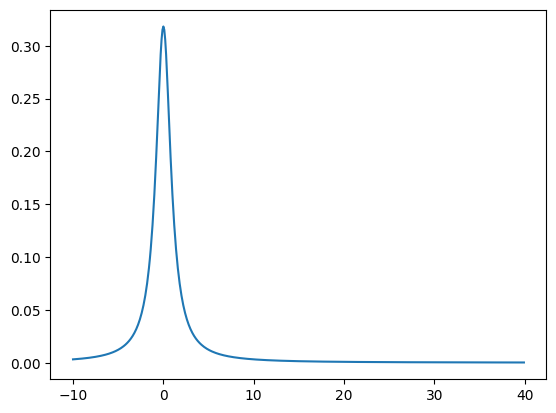

In [4]:
plt.plot(x_eval, y_eval)

In [5]:
satellite_df = pd.read_csv("Mg satellites.csv", sep = '\t')

In [6]:
satellite_df

,line,position,amplitude,FWHM
0,ka2,-0.265,0.500000,0.5410
1,ka1,0.000,1.000000,0.5410
2,ka’,4.740,0.010270,1.1056
3,ka3,8.210,0.067970,0.6264
4,ka3’,8.487,0.034690,0.7349
5,ka4,10.095,0.049050,1.0007
6,ka5,17.404,0.004268,1.4311
7,ka6,20.430,0.003362,0.8656


In [7]:
from functools import partial

def get_source_spectrum_function(satellite_df):
    x_ray_lines = []
    for (position, amplitude, FWHM) in zip(
            satellite_df['position'],
            satellite_df['amplitude'],
            satellite_df['FWHM'],
    ):
        x_ray_line = partial(
            lmfit.lineshapes.lorentzian,
            amplitude = amplitude, center = position, sigma = FWHM/2
        )
        x_ray_lines.append(x_ray_line)
    def source_spectrum_function(x):
        result = 0
        for x_ray_line in x_ray_lines:
            result += x_ray_line(x)
        return result
    return source_spectrum_function

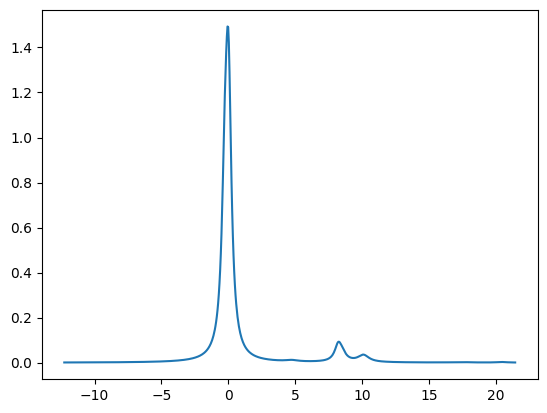

In [9]:
def get_source_spectrum_kernel(satellite_df, dx, threshold = 1e-3):
    source_spectrum_function = get_source_spectrum_function(satellite_df)

    lowest_line_position = min(satellite_df['position'])
    highest_line_position = max(satellite_df['position'])
    f = get_source_spectrum_function(satellite_df)
    n = 1
    while True:
        if f(lowest_line_position - n) <= threshold:
            break
        n += 1
    lower_bound = lowest_line_position - n
    n = 1
    while True:
        if f(highest_line_position + n) <= threshold:
            break
        n += 1
    upper_bound = highest_line_position + n

    x_eval = np.arange(lower_bound, upper_bound + dx, dx)

    return x_eval, source_spectrum_function(x_eval)
    

x, y = get_source_spectrum_kernel(satellite_df, 0.05)
plt.plot(x, y)